# Análise de Dados de Viagens a Serviço do Governo Federal

Este notebook apresenta a análise dos dados de viagens a serviço do Portal da Transparência do Governo Federal. Os dados foram processados utilizando uma arquitetura Medallion (Raw, Silver e Gold), com Python, Pandas e MySQL.

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine
from urllib.parse import quote_plus

plt.style.use("ggplot")

In [3]:
load_dotenv("../.env")

DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(
    f"mysql+mysqlconnector://{DB_USER}:{quote_plus(DB_PASS)}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

print("Conexão realizada com sucesso.")

Conexão realizada com sucesso.


In [4]:
gold_top5_orgaos = pd.read_sql("SELECT * FROM gold_top5_orgaos", engine)
gold_top3_destinos = pd.read_sql("SELECT * FROM gold_top3_destinos", engine)
gold_maior_viagem = pd.read_sql("SELECT * FROM gold_maior_viagem", engine)
gold_tipo_pagamento = pd.read_sql("SELECT * FROM gold_tipo_pagamento", engine)
gold_meio_transporte = pd.read_sql("SELECT * FROM gold_meio_transporte", engine)
gold_uf_destino = pd.read_sql("SELECT * FROM gold_uf_destino", engine)
gold_orgao_maior_gasto = pd.read_sql("SELECT * FROM gold_orgao_maior_gasto", engine)

## 1. Órgãos com maior custo total

In [4]:
gold_top5_orgaos

,nome_orgao_superior,custo_total
0,Ministério da Justiça e Segurança Pública,4.908135e+08
1,Ministério da Defesa,1.570597e+08
2,Ministério da Educação,1.125195e+08
3,Ministério do Meio Ambiente e Mudança do Clima,5.054838e+07
4,Ministério da Previdência Social,4.092148e+07


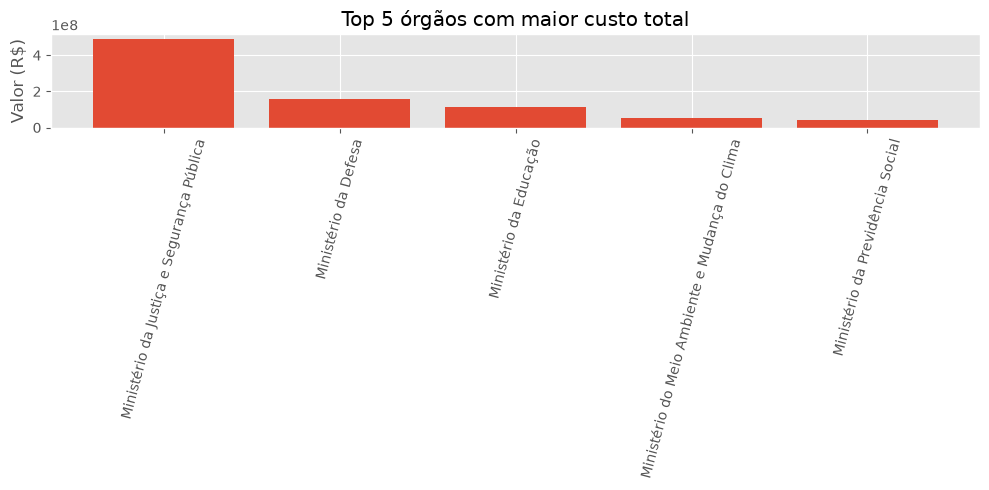

In [5]:
plt.figure(figsize=(10,5))

plt.bar(
    gold_top5_orgaos["nome_orgao_superior"],
    gold_top5_orgaos["custo_total"]
)

plt.title("Top 5 órgãos com maior custo total")
plt.ylabel("Valor (R$)")
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

Os dados mostram que o Ministério da Justiça e Segurança Pública apresentou o maior custo total com viagens no período analisado. Em seguida aparecem o Ministério da Defesa e o Ministério da Educação.

## 2. Destinos com maior custo médio por viagem

In [6]:
gold_top3_destinos

,destino,custo_medio
0,Tejupá,115175.00
1,Chavantes,114557.01
2,Guiyang,112870.41


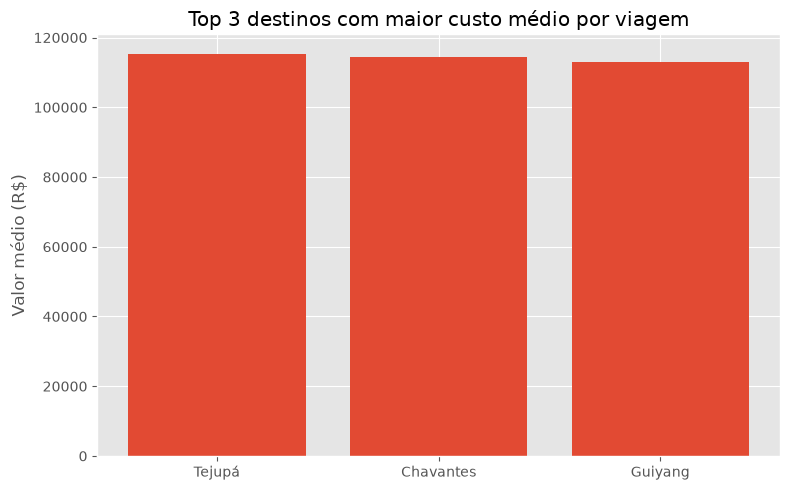

In [7]:
plt.figure(figsize=(8,5))

plt.bar(
    gold_top3_destinos["destino"],
    gold_top3_destinos["custo_medio"]
)

plt.title("Top 3 destinos com maior custo médio por viagem")
plt.ylabel("Valor médio (R$)")

plt.tight_layout()
plt.show()

Os três destinos com maior custo médio por viagem foram Tejupá, Chavantes e Guiyang. Esses valores representam a média do custo das viagens registradas para cada destino durante o período analisado.

## 3. Viagem de maior duração e seu custo total

In [8]:
gold_maior_viagem

,id_viagem,nome_viajante,nome_orgao_superior,duracao_dias,valor_total
0,0000000000020699856,LUISANGELA CORREA FRANCO DE FARIA,Ministério da Previdência Social,383,0.0


A viagem de maior duração registrada possui 383 dias. A consulta apresenta o identificador da viagem, o nome do viajante, a duração e o valor total registrado para esse processo.

Esse resultado permite identificar casos que merecem análise mais detalhada, principalmente quando há longos períodos de afastamento ou valores financeiros relevantes.

## 4. Tipo de pagamento com maior valor médio

In [9]:
gold_tipo_pagamento

,tipo_pagamento,valor_medio
0,DIÁRIAS,2078.28


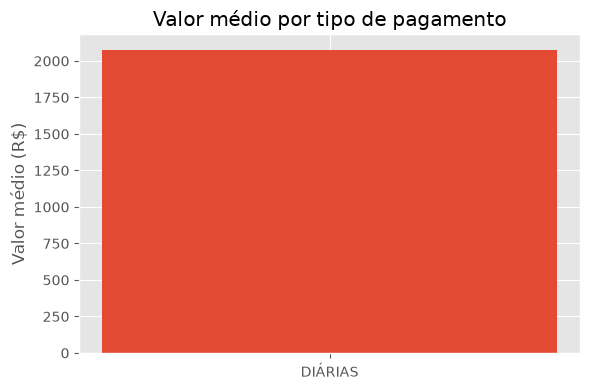

In [10]:
plt.figure(figsize=(6,4))

plt.bar(
    gold_tipo_pagamento["tipo_pagamento"],
    gold_tipo_pagamento["valor_medio"]
)

plt.title("Valor médio por tipo de pagamento")
plt.ylabel("Valor médio (R$)")

plt.tight_layout()
plt.show()

A análise mostra o valor médio do tipo de pagamento registrado na base de dados. Esse resultado permite observar quanto, em média, foi pago para cada categoria de pagamento utilizada nas viagens.

## 5. Meio de transporte mais utilizado

In [11]:
gold_meio_transporte

,meio_transporte,quantidade
0,Veículo Oficial,386424


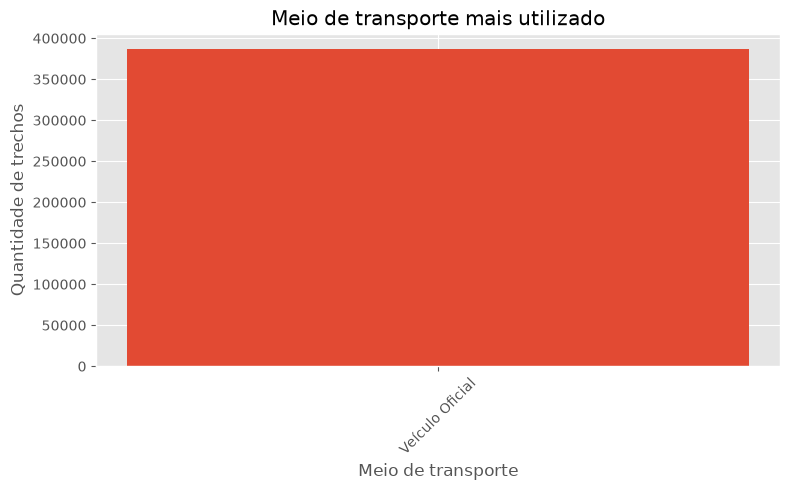

In [12]:
plt.figure(figsize=(8,5))

plt.bar(
    gold_meio_transporte["meio_transporte"],
    gold_meio_transporte["quantidade"]
)

plt.title("Meio de transporte mais utilizado")
plt.xlabel("Meio de transporte")
plt.ylabel("Quantidade de trechos")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

A consulta apresenta o meio de transporte utilizado com maior frequência nos trechos das viagens. Esse resultado permite identificar a principal forma de deslocamento utilizada pelos servidores durante o período analisado.

## 6. UF de destino com maior número de trechos

In [13]:
gold_uf_destino

,uf_destino,quantidade
0,São Paulo,82722


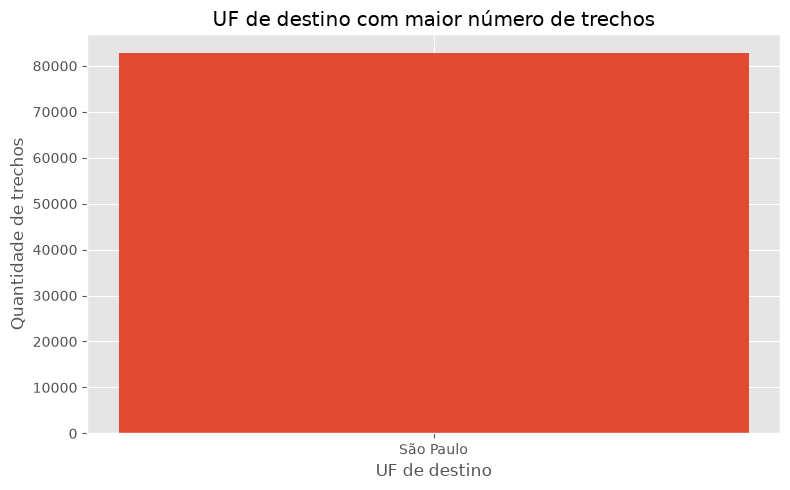

In [14]:
plt.figure(figsize=(8,5))

plt.bar(
    gold_uf_destino["uf_destino"],
    gold_uf_destino["quantidade"]
)

plt.title("UF de destino com maior número de trechos")
plt.xlabel("UF de destino")
plt.ylabel("Quantidade de trechos")

plt.tight_layout()
plt.show()

A consulta mostra a unidade da federação que apareceu com maior frequência como destino dos trechos registrados. Esse resultado indica a concentração dos deslocamentos realizados durante o período analisado.

## 7. Órgão com maior gasto total

In [15]:
gold_orgao_maior_gasto

,nome_orgao_superior,total_pago
0,Ministério da Justiça e Segurança Pública,4.908135e+08


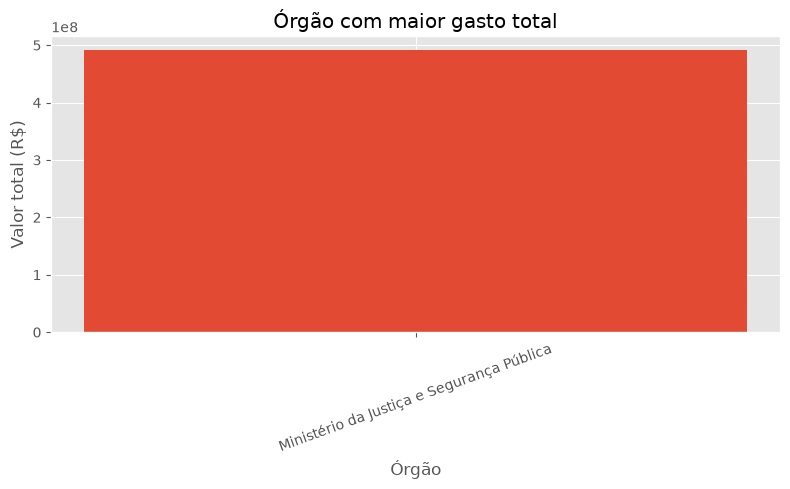

In [16]:
plt.figure(figsize=(8,5))

plt.bar(
    gold_orgao_maior_gasto["nome_orgao_superior"],
    gold_orgao_maior_gasto["total_pago"]
)

plt.title("Órgão com maior gasto total")
plt.xlabel("Órgão")
plt.ylabel("Valor total (R$)")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

A consulta identifica o órgão que apresentou o maior gasto total com viagens a serviço. No período analisado, o Ministério da Justiça e Segurança Pública foi o órgão com o maior volume de despesas registradas.

# Conclusão

A análise dos dados permitiu identificar os órgãos com maiores despesas, os destinos com maior custo médio, a viagem de maior duração, o tipo de pagamento utilizado, o meio de transporte mais frequente e a unidade da federação com maior número de trechos.

O uso da arquitetura Medallion possibilitou organizar o processo de tratamento dos dados em três camadas (Raw, Silver e Gold), facilitando a limpeza, transformação e análise das informações.

Com o apoio do Python, Pandas, SQLAlchemy e MySQL foi possível automatizar o pipeline de dados e gerar consultas que respondem aos principais questionamentos propostos no projeto.